<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2_ext/04_causal_elasticities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimating the Average Price Elasticity with Double Machine Learning

This notebook is the fourth of five labs that accompany [Bach et al. (2025)](https://arxiv.org/abs/2501.00382). It requires the embeddings saved in **Lab 2**.

In Lab 1, a regression of quantity on price yielded an estimate of $\delta$ between about $-0.3$ and $-0.1$, which implies almost no response of demand to prices. Lab 3 showed why this estimate is suspect and what we should condition on instead. In this lab, we estimate the average price elasticity by double machine learning (DML).

## The Causal Model

**Assumption 1 (structural equation model).** In each period,

$$Q_{it} = a_t(S_{it}, \epsilon_{it})\,P_{it} + q_t(S_{it}, \epsilon_{it}), \qquad
P_{it} = p_t(S_{it}, \epsilon^p_{it}), \qquad
S_{it} = s_t(S_{i,t-1}, \epsilon^s_{it}),$$

where $a_t, q_t, p_t, s_t$ are nonparametric functions and the shocks are mutually independent. The state

$$S_{it} := (Q_{i,t-1},\; P_{i,t-1},\; X_{it})$$

consists of lagged quantity and price together with the product characteristics $X_{it}$, that is, the embeddings from Lab 2 and the tabular controls.

**The role of the lagged outcome.** $Q_{i,t-1}$ summarizes everything that made the product sell in the previous period: visibility in search results, accumulated reviews, brand strength and perceived quality. These are the same latent factors that allow a seller to sustain a higher price. Lab 3 illustrated this point: once $Q_{i,t-1}$ is included, the embeddings no longer improve the prediction of $Q_{it}$.

**The causal parameter.** Let $A_{it} := a_t(S_{it}, \epsilon_{it})$. The potential outcome at log price $p$ is $Q_{it}(p) = A_{it}\,p + q_t(S_{it}, \epsilon_{it})$, so $A_{it}$ is the causal effect of a one-unit increase in the log price. In this lab, we estimate its average, $\alpha_t := E[A_{it}]$. Lab 5 estimates how it varies across products.

## Estimation by Partialling Out

Conditioning on $S_{it}$ blocks all non-causal paths between price and quantity. Let $\ell(S_{it}) := E[Q_{it}\mid S_{it}]$ and $m(S_{it}) := E[P_{it}\mid S_{it}]$. Partialling out the state gives the residualized equation

$$Q^{\perp}_{it} = \delta\,P^{\perp}_{it} + e_{it}, \qquad
Q^{\perp}_{it} := Q_{it} - \ell(S_{it}), \quad
P^{\perp}_{it} := P_{it} - m(S_{it}),$$

which we estimate by double machine learning ([Chernozhukov et al., 2018](https://arxiv.org/abs/1608.00060)). In the first stage, we estimate $\ell$ and $m$ with machine learning methods and cross-fitting. In the second stage, we regress the outcome residual on the price residual by OLS.

The estimator is based on a Neyman orthogonal score, so small errors in the estimated nuisance functions $\hat\ell$ and $\hat m$ have no first-order effect on $\hat\delta$. Orthogonality is also the reason why estimated embeddings do not invalidate the inference, provided that they were estimated on independent data. This is the case here: Lab 2 fine-tuned the network on the fine-tuning products, and all estimates below use the estimation products only.

Throughout, we cluster the standard errors at the product level, since each product contributes up to 13 correlated observations.

In [1]:
%pip install -q doubleml lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.8/607.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.7/531.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from doubleml import DoubleMLData, DoubleMLPLR
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

palette = sns.color_palette("colorblind")
warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.width", 140)

CONFIDENCE = 0.90
RANK_TO_DEMAND = 2.0   # 1 / theta-hat, theta-hat ~ 0.5 for toys (He & Hollenbeck)

## Data

We load the data saved in Lab 2 from Google Drive. If the file is not found there, the cell also looks for a copy uploaded to the current session.

In [4]:
ARTIFACT = "full_v2_ext.parquet"
drive_path = f"/content/drive/MyDrive/demand_labs_v2_ext/{ARTIFACT}"

# Colab gives every notebook its own machine, so /content does not carry across
# labs. Google Drive does.
if os.path.isdir("/content") and not os.path.exists(drive_path):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"could not mount Drive ({type(exc).__name__})")

path = next((p for p in [drive_path, f"/content/{ARTIFACT}", ARTIFACT]
             if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(
        f"{ARTIFACT} not found. Run Lab 2 "
        "(02_finetune_embeddings.ipynb) first and let it save to Google Drive, "
        "or upload the file into this session.")

df = pd.read_parquet(path)
print(f"loaded {path}")
print(f"{df['ASIN'].nunique():,} products, {len(df):,} rows, "
      f"{df['period'].nunique()} periods")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size"),
                              in_sample=("in_sample", "sum")))

Mounted at /content/drive
loaded /content/drive/MyDrive/demand_labs_v2_ext/full_v2_ext.parquet
7,549 products, 83,777 rows, 14 periods
            products   rows  in_sample
split                                 
estimation      3775  41736      37940
finetune        3774  42041      38247


The data contain 7,549 products and 83,777 product-periods. Next, we define the groups of variables and restrict the sample to the estimation sample $I_2$, the products whose embeddings were not used to train the network: 37,940 observations of 3,726 products. The first observation of each product has no lagged values and is not part of it.

In [5]:
emb_cols = [c for c in df.columns if c.startswith("emb_")]
pca_cols = [c for c in df.columns if c.startswith("pca_")]
sim_cols = [c for c in df.columns if c.startswith("similarity_cluster_")]
sub_cols = [c for c in df.columns if c.startswith("sub_")]

lag_controls = ["Q_t-1", "P_bb_t-1"]
tab_controls = ["RATING_t-1", "REVIEW_COUNT_t-1", "n_offers",
                "n_offers_fba", "n_offers_fbm", "lightning_deal", "is_fba"]

periods = sorted(df["period"].unique())[1:]   # first period is the baseline
period_cols = [f"period_{p}" for p in periods]
for p in periods:
    df[f"period_{p}"] = (df["period"] == p).astype(int)

OUTCOME, TREATMENT = "Q_t", "P_bb_t"

# I_2: estimate only on products the embeddings were not trained on, and only
data = (df[(df["split"] == "estimation") & df["in_sample"]]
        .dropna(subset=lag_controls + tab_controls + [OUTCOME, TREATMENT])
        .reset_index(drop=True))

print(f"estimation sample: {len(data):,} observations, "
      f"{data['ASIN'].nunique()} products, {data['period'].nunique()} periods")

estimation sample: 37,940 observations, 3726 products, 13 periods


## Specifications of the Control Function

We consider the following specifications. $X^o_{it}$ denotes the tabular controls (ratings, review counts, offer counts, deal and FBA indicators) together with the subcategory and period dummies.

| Label | Control function $\gamma_t(S_{it})$ |
|---|---|
| **I-1** Linear $(P_{t-1},Q_{t-1})$ | lagged price and quantity only |
| **I-1** Linear $(P_{t-1},Q_{t-1},X^e,X^o)$ | plus the 256 embeddings |
| **I-1** Linear $(P_{t-1},Q_{t-1},X^{sim},X^o)$ | plus the 5 cluster similarities |
| **I-2** Linear with interactions | plus interactions of $P_{t-1},Q_{t-1}$ with $X^{sim}$ |
| **I-3** Boosted trees $(\cdot,X^e,X^o)$ | fully nonparametric, embeddings |
| **I-3** Boosted trees $(\cdot,X^{sim},X^o)$ | fully nonparametric, similarities |

In [6]:
X_o = tab_controls + sub_cols + period_cols

# I-2: interactions of the lagged state with the cluster similarities
inter_cols = []
for lag in lag_controls:
    for s in sim_cols:
        name = f"int_{lag}_{s}"
        data[name] = data[lag] * data[s]
        inter_cols.append(name)

SPECS = {
    "I-1 Linear (P,Q lags)":        (lag_controls, "linear"),
    "I-1 Linear (+ embeddings)":    (lag_controls + emb_cols + X_o, "linear"),
    "I-1 Linear (+ similarities)":  (lag_controls + sim_cols + X_o, "linear"),
    "I-2 Linear (+ interactions)":  (lag_controls + sim_cols + X_o + inter_cols, "linear"),
    "I-3 Boosted (+ embeddings)":   (lag_controls + emb_cols + X_o, "dml"),
    "I-3 Boosted (+ similarities)": (lag_controls + sim_cols + X_o, "dml"),
}
print(f"{len(inter_cols)} interaction terms; {len(X_o)} tabular/dummy controls")

10 interaction terms; 31 tabular/dummy controls


## Linear Specifications

We first estimate the linear specifications by OLS, entering the control function linearly, with standard errors clustered by product.

In [7]:
def lin_model(frame, treatment, controls, outcome=OUTCOME, level=CONFIDENCE):
    """OLS of outcome on treatment + controls, clustered by product."""
    X = sm.add_constant(frame[[treatment] + controls], has_constant="add")
    res = sm.OLS(frame[outcome], X).fit(
        cov_type="cluster", cov_kwds={"groups": frame["ASIN"]})
    ci = res.conf_int(alpha=1 - level)
    return {
        "coef": res.params[treatment],
        "se": res.bse[treatment],
        "ci_lo": ci.loc[treatment, 0],
        "ci_hi": ci.loc[treatment, 1],
        "pval": res.pvalues[treatment],
    }


results = {}
for label, (controls, kind) in SPECS.items():
    if kind != "linear":
        continue
    results[label] = lin_model(data, TREATMENT, controls)
    r = results[label]
    print(f"{label:32s} delta={r['coef']:+.3f}  "
          f"[{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]  se={r['se']:.3f}")

I-1 Linear (P,Q lags)            delta=-0.763  [-0.826, -0.700]  se=0.038


/tmp/ipykernel_2372/439755719.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  res = sm.OLS(frame[outcome], X).fit(


I-1 Linear (+ embeddings)        delta=-0.789  [-0.850, -0.728]  se=0.037


/tmp/ipykernel_2372/439755719.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  res = sm.OLS(frame[outcome], X).fit(


I-1 Linear (+ similarities)      delta=-0.795  [-0.856, -0.735]  se=0.037
I-2 Linear (+ interactions)      delta=-0.799  [-0.861, -0.738]  se=0.037


/tmp/ipykernel_2372/439755719.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  res = sm.OLS(frame[outcome], X).fit(


The specification with lagged price and quantity only does not involve the embeddings. On our estimation sample, it gives $\hat\delta = -0.763$ (90% CI $[-0.826, -0.700]$).

**Note:** The `SingularMatrixWarning`s indicate that the design matrix is rank-deficient, since the full set of subcategory dummies is collinear with the constant. `statsmodels` then uses a pseudo-inverse, and the coefficient on price remains identified.

## DML Estimates

For a nonparametric control function, we estimate both nuisance functions with boosted trees (LightGBM) and let the `DoubleML` package handle the cross-fitting with three folds. Passing `cluster_cols="ASIN"` keeps all observations of a product in the same fold, which prevents a product's own history from leaking across folds, and yields cluster-robust standard errors.

In [8]:
def _r2(y_true, y_pred):
    """R^2 metric in the signature DoubleML.evaluate_learners expects."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    return r2_score(y_true[ok], y_pred[ok])


def dml_plr(frame, controls, label, n_folds=3, level=CONFIDENCE):
    """Partially linear DML with cluster-aware cross-fitting."""
    cols = [OUTCOME, TREATMENT, "ASIN"] + controls
    dml_data = DoubleMLData(frame[cols], y_col=OUTCOME, d_cols=TREATMENT,
                            x_cols=controls, cluster_cols="ASIN")

    learner = dict(n_estimators=500, learning_rate=0.02, random_state=42, verbose=-1)
    obj = DoubleMLPLR(dml_data,
                      ml_l=LGBMRegressor(**learner),
                      ml_m=LGBMRegressor(**learner),
                      score="partialling out", n_folds=n_folds)
    obj.fit(store_predictions=True)

    ci = obj.confint(level=level)
    scores = obj.evaluate_learners(metric=_r2)
    return obj, {
        "coef": float(obj.coef[0]), "se": float(obj.se[0]),
        "ci_lo": float(ci.iloc[0, 0]), "ci_hi": float(ci.iloc[0, 1]),
        "pval": float(obj.pval[0]),
        "r2_l": float(np.mean(scores["ml_l"])),
        "r2_m": float(np.mean(scores["ml_m"])),
    }


dml_objects = {}
for label, (controls, kind) in SPECS.items():
    if kind != "dml":
        continue
    np.random.seed(3141)
    obj, res = dml_plr(data, controls, label)
    dml_objects[label], results[label] = obj, res
    print(f"{label:32s} delta={res['coef']:+.3f}  "
          f"[{res['ci_lo']:+.3f}, {res['ci_hi']:+.3f}]  "
          f"R2(Q|S)={res['r2_l']:.3f}  R2(P|S)={res['r2_m']:.3f}")

I-3 Boosted (+ embeddings)       delta=-0.727  [-0.792, -0.663]  R2(Q|S)=0.905  R2(P|S)=0.977
I-3 Boosted (+ similarities)     delta=-0.750  [-0.809, -0.691]  R2(Q|S)=0.907  R2(P|S)=0.978


## Results

The printout above reports the two boosted-tree estimates together with the out-of-fold $R^2$ of the first-stage learners. Expect the learners to predict the outcome and the price well, since the lagged state alone explains most of their variation (Lab 3). The table collects all estimates; the last column converts them into demand elasticities.

In [9]:
table = pd.DataFrame(results).T[["coef", "se", "ci_lo", "ci_hi", "pval"]]
table["demand elasticity"] = table["coef"] * RANK_TO_DEMAND
table.index.name = "Specification"
table.round(3)

,coef,se,ci_lo,ci_hi,pval,demand elasticity
Specification,,,,,,
"I-1 Linear (P,Q lags)",-0.763,0.038,-0.826,-0.700,0.0,-1.526
I-1 Linear (+ embeddings),-0.789,0.037,-0.850,-0.728,0.0,-1.578
I-1 Linear (+ similarities),-0.795,0.037,-0.856,-0.735,0.0,-1.591
I-2 Linear (+ interactions),-0.799,0.037,-0.861,-0.738,0.0,-1.599
I-3 Boosted (+ embeddings),-0.727,0.039,-0.792,-0.663,0.0,-1.454
I-3 Boosted (+ similarities),-0.750,0.036,-0.809,-0.691,0.0,-1.500


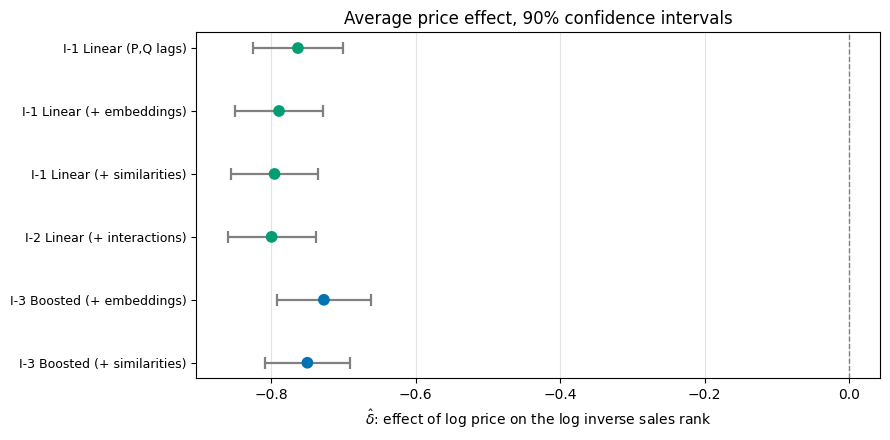

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = list(table.index)
y = np.arange(len(labels))
colors = [palette[0] if lbl.startswith("I-3") else palette[2] for lbl in labels]

ax.errorbar(table["coef"], y,
            xerr=[table["coef"] - table["ci_lo"], table["ci_hi"] - table["coef"]],
            fmt="o", ms=7, lw=1.6, capsize=4, capthick=1.6,
            ecolor="gray", linestyle="none", color="none")
ax.scatter(table["coef"], y, c=colors, s=55, zorder=3)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("$\\hat{\\delta}$: effect of log price on the log inverse sales rank")
ax.set_title(f"Average price effect, {CONFIDENCE:.0%} confidence intervals")
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
plt.show()

## Diagnostics

The DML estimator is a regression of one residual on another, so the residuals are a quick way to check that there is identifying variation. We plot the residuals of the boosted-tree specification with similarities.

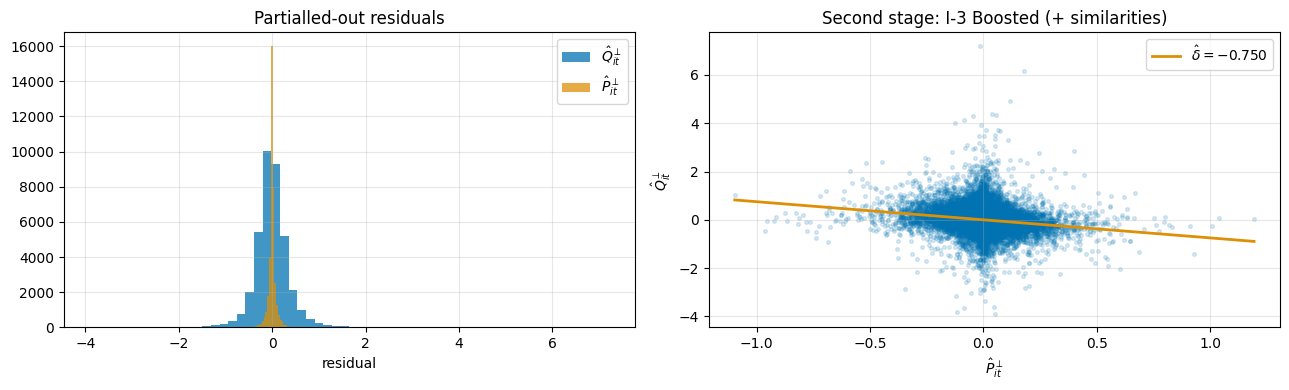

sd of price residual:    0.0899
sd of quantity residual: 0.3998


In [11]:
label = "I-3 Boosted (+ similarities)"
obj = dml_objects[label]
Q_perp = data[OUTCOME].values - obj.predictions["ml_l"][:, 0, 0]
P_perp = data[TREATMENT].values - obj.predictions["ml_m"][:, 0, 0]
delta_hat = results[label]["coef"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(Q_perp, bins=60, alpha=0.75, color=palette[0],
             label="$\\hat{Q}^{\\perp}_{it}$")
axes[0].hist(P_perp, bins=60, alpha=0.75, color=palette[1],
             label="$\\hat{P}^{\\perp}_{it}$")
axes[0].set_xlabel("residual")
axes[0].set_title("Partialled-out residuals")
axes[0].legend()

axes[1].scatter(P_perp, Q_perp, s=7, alpha=0.15, color=palette[0])
grid = np.linspace(P_perp.min(), P_perp.max(), 100)
axes[1].plot(grid, delta_hat * grid, color=palette[1], lw=2,
             label=f"$\\hat{{\\delta}} = {delta_hat:.3f}$")
axes[1].set_xlabel("$\\hat{P}^{\\perp}_{it}$")
axes[1].set_ylabel("$\\hat{Q}^{\\perp}_{it}$")
axes[1].set_title(f"Second stage: {label}")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"sd of price residual:    {P_perp.std():.4f}")
print(f"sd of quantity residual: {Q_perp.std():.4f}")

## Discussion

**The price effect is negative, sizable and stable across specifications.** On our split, the specification with the lagged state only gives $-0.763$. Multiplying by the Pareto factor of about 2 gives demand elasticities of roughly $-1.4$ to $-1.5$: a 1% price increase reduces units sold by about 1.4% to 1.5%. This is a plausible magnitude for a consumer good with close substitutes and far from the naive estimate in Lab 1.
